In [1]:
from ioMicro import *

import numpy as np
import matplotlib.pyplot as plt

In [4]:
import napari

In [29]:
import glob
import re

# Define a function to extract the numerical part from the filename
def extract_number(filename):
    match = re.search(r'H(\d+)', filename)  # This assumes numbers follow 'H' (like H123, H456, etc.)
    return int(match.group(1)) if match else float('inf')  # Return a large value if no match found

# Get the list of files and sort them numerically based on the number after 'H'
flds = sorted(glob.glob(r'D:\241207_WTC11_SFv7\H*_MER*'), key=extract_number)

# Print sorted list
flds

['D:\\241207_WTC11_SFv7\\H0_MER',
 'D:\\241207_WTC11_SFv7\\H1_MER',
 'D:\\241207_WTC11_SFv7\\H2_MER',
 'D:\\241207_WTC11_SFv7\\H3_MER',
 'D:\\241207_WTC11_SFv7\\H4_MER',
 'D:\\241207_WTC11_SFv7\\H5_MER',
 'D:\\241207_WTC11_SFv7\\H6_MER',
 'D:\\241207_WTC11_SFv7\\H7_MER',
 'D:\\241207_WTC11_SFv7\\H8_MER',
 'D:\\241207_WTC11_SFv7\\H9_MER',
 'D:\\241207_WTC11_SFv7\\H10_MER',
 'D:\\241207_WTC11_SFv7\\H11_MER',
 'D:\\241207_WTC11_SFv7\\H12_MER',
 'D:\\241207_WTC11_SFv7\\H13_MER',
 'D:\\241207_WTC11_SFv7\\H14_MER',
 'D:\\241207_WTC11_SFv7\\H15_MER',
 'D:\\241207_WTC11_SFv7\\H16_MER',
 'D:\\241207_WTC11_SFv7\\H17_MER']

In [30]:
drifts,flds,fov_,fl_refd = np.load(dec.drift_fl,allow_pickle=True)

In [31]:
from dask import array as da

ims_ =[]
# flds = glob.glob(r'D:\241207_WTC11_SFv7\H*_MER*')
fov = 'Conv_zscan1_172'
for drft,fld in zip(drifts,flds):
    im = read_im(fld+os.sep+fov_)[np.newaxis]
    drift = np.round(drft[0]).astype(int)
    ims_.append(da.roll(im,drift,axis=[-3,-2,-1]))
ims_ = da.concatenate(ims_)
napari.view_image(ims_)

Viewer(camera=Camera(center=(0.0, 1399.5, 1399.5), zoom=0.18083928571428567, angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True), cursor=Cursor(position=(8.0, 1.0, 19.0, 0.0, 0.0), scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=1.0), dims=Dims(ndim=5, ndisplay=2, order=(0, 1, 2, 3, 4), axis_labels=('0', '1', '2', '3', '4'), rollable=(True, True, True, True, True), range=(RangeTuple(start=0.0, stop=17.0, step=1.0), RangeTuple(start=0.0, stop=3.0, step=1.0), RangeTuple(start=0.0, stop=39.0, step=1.0), RangeTuple(start=0.0, stop=2799.0, step=1.0), RangeTuple(start=0.0, stop=2799.0, step=1.0)), margin_left=(0.0, 0.0, 0.0, 0.0, 0.0), margin_right=(0.0, 0.0, 0.0, 0.0, 0.0), point=(8.0, 1.0, 19.0, 1399.0, 1399.0), last_used=0), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False), layers=[<Image layer 'ims_' at 0x17dc32ba800>], help='use <2> for transform', status='Ready', tooltip=Tooltip(visible=False, text=''), theme='dark', title='napari', mouse_over

In [2]:
data_folder = r'D:\241207_WTC11_SFv7_HMERFISH_Analysis'

In [58]:
# spots = np.load(data_folder+'\decodedNew_Conv_zscan1_000--.npz', allow_pickle=True)

In [7]:
save_folder=r'D:\241207_WTC11_SFv7_HMERFISH_Analysis'#
#r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024_HMERFISH_AnalysisGFP'
ifov = 172
fov = 'Conv_zscan1_'+str(ifov).zfill(3)
dec = decoder_simple(save_folder,fov,set_='')

In [11]:
dec.ncols = 3
dec.load_decoded()
dec.dist_best=np.load(dec.decoded_fl)['dist_best']

Loaded decoded: -2.0609865188598633


In [12]:
dec.drift_fl 

'D:\\241207_WTC11_SFv7_HMERFISH_Analysis\\driftNew_Conv_zscan1_172--.pkl'

In [8]:
np.load(dec.drift_fl, allow_pickle = True)

[[[array([ -0.6012072, -15.794516 ,  -7.1039243], dtype=float32),
   array([ 0.5947494, 15.829344 ,  7.1416926], dtype=float32),
   array([ 0.61422205, 15.724324  ,  7.0278077 ], dtype=float32),
   262,
   130],
  [array([ 5.493981, 17.547733, 20.924192], dtype=float32),
   array([ -5.493981, -17.547733, -20.924192], dtype=float32),
   array([ -8.336562, -17.807676, -20.980482], dtype=float32),
   37,
   27],
  [array([ 0.10505193,  5.72758   , 11.438527  ], dtype=float32),
   array([ -0.09943758,  -5.711954  , -11.465035  ], dtype=float32),
   array([ -0.11781549,  -5.7631035 , -11.378263  ], dtype=float32),
   316,
   139],
  [array([0.05868546, 0.94497895, 5.6295676 ], dtype=float32),
   array([-0.0364834, -0.9409471, -5.6276083], dtype=float32),
   array([-0.10758804, -0.9538595 , -5.633883  ], dtype=float32),
   337,
   153],
  [array([0.06276658, 3.9556212 , 3.8728373 ], dtype=float32),
   array([-0.06935018, -3.92371   , -3.8679333 ], dtype=float32),
   array([-0.0478975, -4.027

Loaded decoded: -2.380000114440918
Fraction of GFP decoded above confidence: 0.6325329372610501


Text(0.5, 1.0, '0.14')

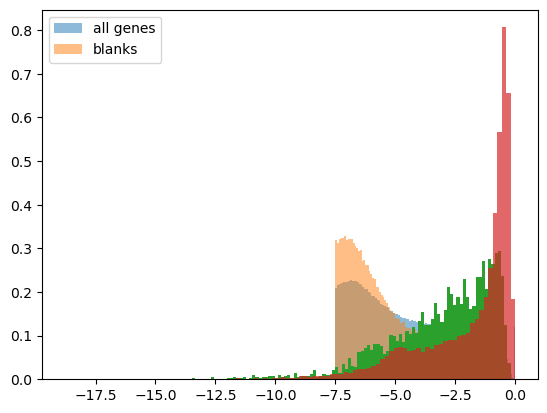

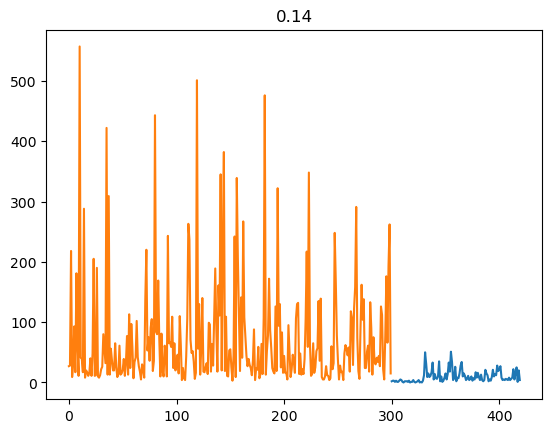

In [24]:
save_folder=r'D:\241207_WTC11_SFv7_HMERFISH_Analysis'#
#r'\\192.168.0.15\cherry2\Zane\300CRE_Schizo_withT7_AdamRNA_WTC11__10_19_2024_HMERFISH_AnalysisGFP'
ifov = 100
fov = 'Conv_zscan1_'+str(ifov).zfill(3)
#save_folder =r'\\merfish19\merfish19\20240422_R136BICAN2kgene\MERFISHPlate3_4\AnalysisBB_P34_bkremove'
#save_folder =r'R:\Roy\2000gnMERFISH_DCBB_5_9_2024\MERFISH_AnalysisP5P6'
save_fl_ref = r'D:\241207_WTC11_SFv7_HMERFISH_Analysis\scores_ref.pkl'
dec = decoder_simple(save_folder,fov,set_='')
dec.ncols = 3
dec.load_decoded()
dec.dist_best=np.load(dec.decoded_fl)['dist_best']
if False:
    scoresRef = get_score_per_color(dec,include_dbits=True)
    pickle.dump(scoresRef,open(r'D:\241207_WTC11_SFv7_HMERFISH_Analysis\scoresRef.pkl','wb'))
else:
    scoresRef = pickle.load(open(r'D:\241207_WTC11_SFv7_HMERFISH_Analysis\scoresRef.pkl','rb'))
get_score_withRef(dec,scoresRef,plt_val=True,gene=None,iSs = None,th_min=-7.5,include_dbits=True)

gfp_signal_col0 = save_folder+os.sep+dec.fov+r'--H17_MER--col0__Xhfits.npz'
gfp_signal_col1 = save_folder+os.sep+dec.fov+r'--H17_MER--col1__Xhfits.npz'
Xh0 = np.load(gfp_signal_col0)['Xh']
Xh1 = np.load(gfp_signal_col1)['Xh']

Xh0_ = Xh0[(Xh0[:,-2]>0.6)&(Xh0[:,-1]>np.exp(9.5))]### Threshild based on quality of spot
Xh1_ = Xh1[(Xh1[:,-2]>0.6)&(Xh1[:,-1]>np.exp(9.5))]
X0 = Xh0_[:,:3]
X1 = Xh1_[:,:3]
from scipy.spatial import KDTree
dists,inds = KDTree(X0).query(X1)
X1F = Xh1_[(dists<2)][:,[0,1,2,-1]]
if False:
    plt.hist(np.log(Xh0_[:,-1]),density=True,bins=30)
    plt.hist(np.log(Xh0_[inds[(dists<2)],-1]),density=True,bins=30,alpha=0.5)
    plt.hist(np.log(Xh1_[:,-1]),density=True,bins=30)
    plt.hist(np.log(Xh1_[dists<1.5,-1]),density=True,bins=30,alpha=0.5)
if False:
    imGFP = read_im(r'D:\241207_WTC11_SFv7\H17_MER'+os.sep+dec.fov)
    import napari
    V = napari.view_image(imGFP)
    V.add_points(X1F[:,:3],face_color=[0,0,0,0],edge_color='r')
### apply drift
drifts,flds,fov_,fl_ref = np.load(dec.drift_fl,allow_pickle=True)
from worker_ZaneWTC_HGFP import *
fl = r'D:\241207_WTC11_SFv7\H17_MER'+os.sep+dec.fov
drift = get_best_translation_pointsV2(fl,fl_ref,save_folder,'',resc=5)
X1FD = X1F.copy()
X1FD[:,:3]=X1F[:,:3]+drift[0]

X_MERFISH = np.nanmean(dec.XH_pruned[:,:,:3],axis=1)
tree = KDTree(X_MERFISH)
dist,indMER = tree.query(X1FD[:,:3],workers=10)

keepMER = indMER[dist<2]

XH_pruned = dec.XH_pruned[keepMER]
scoreA = dec.scoreA[keepMER]
icodesN = dec.icodesN[keepMER]
ibad = [ign for ign,gn in enumerate(dec.gns_names) if 'blank' in gn]
isbad = np.in1d(icodesN,ibad)
isgood=~isbad

plt.hist(scoreA[isbad],density=True,bins=100)
plt.hist(scoreA[isgood],density=True,bins=100,alpha=0.7);

th=-2 ## this is your final decided threshold
np.sum(dec.scoreA>th),np.sum(scoreA>th)
X1FD.shape,scoreA.shape
print("Fraction of GFP decoded above confidence:",np.sum(scoreA>th)/len(X1FD))#,len(scoreA)/len(X1FD)

XH_prunedf = XH_pruned[scoreA>th]
scoreAf = scoreA[scoreA>th]
icodesNf = icodesN[scoreA>th]
dist_bestf = dec.dist_best[keepMER][scoreA>th]
bigSpot = X1FD[dist<2][scoreA>th][:,-1]>np.exp(12)
#XH_prunedf = XH_pruned[scoreA>th]

_,cts = np.unique(list(icodesNf)+list(np.arange(len(dec.gns_names))),return_counts=True)
cts = cts-1
plt.figure()
plt.plot(ibad,cts[ibad])
igood = np.setdiff1d(np.arange(len(cts)),ibad)
plt.plot(igood,cts[igood])
plt.title(np.round(np.mean(cts[ibad])/np.mean(cts[igood]),2))

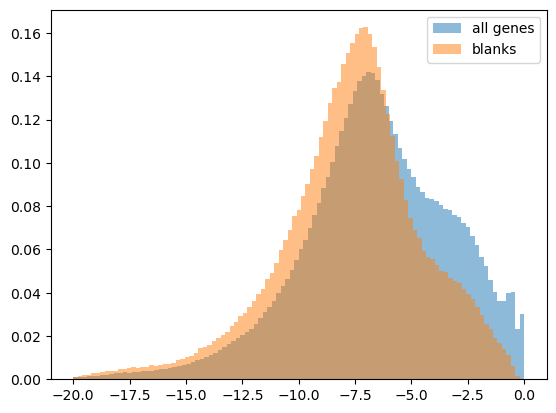

In [16]:
get_score_withRef(dec,scoresRef,plt_val=True,gene=None,iSs = None,th_min=-20,include_dbits=True)

### Newer code

In [20]:
# Specify analysis folder of decoded fov files and create decoder object
save_folder=r'D:\241207_WTC11_SFv7_HMERFISH_Analysis_redo'
ifov = 30
fov = 'Conv_zscan1_'+str(ifov).zfill(3)
#save_folder =r'\\merfish19\merfish19\20240422_R136BICAN2kgene\MERFISHPlate3_4\AnalysisBB_P34_bkremove'
#save_folder =r'R:\Roy\2000gnMERFISH_DCBB_5_9_2024\MERFISH_AnalysisP5P6'
save_fl_ref = r'D:\241207_WTC11_SFv7_HMERFISH_Analysis_redo\scores_ref.pkl'
dec = decoder_simple(save_folder,fov,set_='')
dec.ncols = 3
dec.load_decoded()
dec.dist_best=np.load(dec.decoded_fl)['dist_best']

Loaded decoded: -0.7090003490447998


In [41]:
XH_pruned.shape

(801013, 6, 10)

In [58]:
XH_pruned = dec.XH_pruned

In [59]:
XH_pruned[:20, :, -1]

array([[nan,  0.,  6., 15., 21., 48.],
       [nan,  0.,  6., 24., 30., 48.],
       [nan,  0., 15., 30., 48., 49.],
       [nan,  0., 15., 30., 48., 49.],
       [nan,  0., 15., 30., 48., 49.],
       [nan,  0., 27., 42., 48., 49.],
       [nan,  0., 36., 39., 48., 49.],
       [nan,  0., 36., 39., 48., 49.],
       [nan,  0., 36., 39., 48., 49.],
       [nan,  0., 15., 24., 39., 49.],
       [nan,  0., 21., 27., 42., 49.],
       [nan,  0.,  9., 24., 33., 48.],
       [nan,  0.,  9., 24., 33., 48.],
       [nan,  0., 18., 24., 42., 48.],
       [nan,  0., 12., 30., 42., 48.],
       [nan,  0.,  6., 36., 42., 48.],
       [nan,  0.,  3., 18., 21., 49.],
       [nan,  0.,  6., 24., 30., 49.],
       [nan,  0.,  6., 24., 30., 49.],
       [nan,  0., 15., 30., 48., 49.]])

In [3]:
# Read image data from each fov using read_im function from ioMicro

zarr_files = r'D:\241207_WTC11_SFv7\H9_MER\Conv_zscan1_*.zarr'
files = list(sorted(list(glob.glob(zarr_files))))
print(f"Found {len(files)} files to segment")

im_path = r'D:\241207_WTC11_SFv7\H9_MER\*'
imgs = [read_im(im_path) for im_path in files]
# imgs_DAPI = [read_im(im_path) for im_path in files]

Found 184 files to segment


In [29]:
x = np.array(imgs[0][0,0,:,:])
x_b = cv2.blur(x, ksize=(100,100))

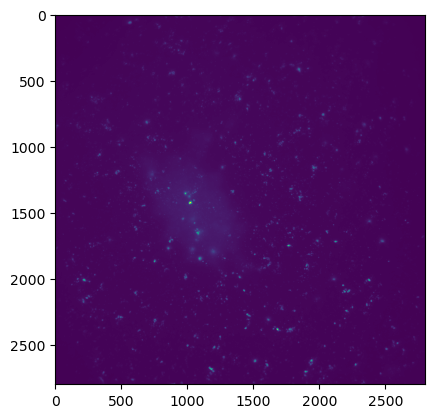

In [25]:
plt.imshow(x)

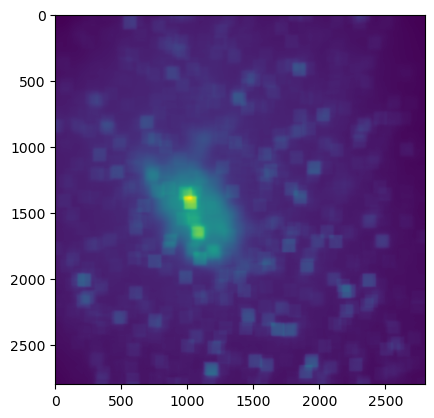

In [30]:
plt.imshow(x_b)

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.17787675e-07,
        8.01138805e-06, 3.98431201e-05, 1.05772293e-04, 2.00571102e-04,
        3.17220757e-04, 4.70890714e-04, 5.98635475e-04, 6.94369992e-04,
        8.15437288e-04, 9.27728152e-04, 1.00970756e-03, 1.06358434e-03,
        1.12137658e-03, 1.06196990e-03, 9.70445092e-04, 8.35916938e-04,
        6.90678163e-04, 5.77484939e-04, 4.64429032e-04, 3.56540116e-04,
        2.78334923e-04, 2.18004306e-04, 1.77635464e-04, 1.46509926e-04,
        1.28262636e-04, 1.11976999e-04, 9.58992966e-05, 8.59262563e-05,
        7.62356938e-05, 7.01486867e-05, 6.46599835e-05, 5.96636551e-05,
        5.72920174e-05, 5.37335802e-05, 4.99318980e-05, 4.65205846e-05,
        4.28405249e-05, 3.88289459e-05, 3.63670722e-05, 3.47330159e-05,
        3.25967765e-05, 3.26340479e-05, 3.17120713e-05, 3.11490771e-05,
        3.16081037e-05, 3.08195195e-05, 3.02800651e-05, 2.92148879e-05,
        2.84145338e-05, 2.79868935e-05, 2.68373653e-05, 2.604093

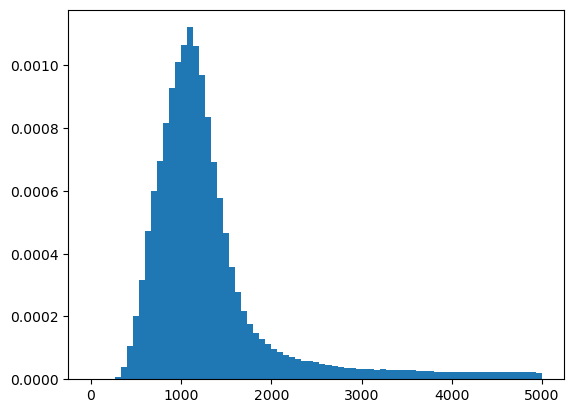

In [16]:
plt.hist(np.ravel(x), bins=75, density=True, range=(0,5000))

(array([ 12041.,   8638.,  20209.,  27142.,   6981.,  33488.,  68162.,
         78745.,  77531., 468076.]),
 array([28.5, 30.5, 32.5, 34.5, 36.5, 38.5, 40.5, 42.5, 44.5, 46.5, 48.5]),
 <BarContainer object of 10 artists>)

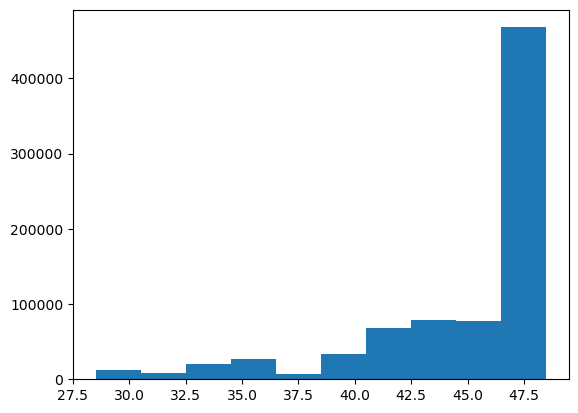

In [40]:
plt.hist(np.mean(XH_pruned[:, :, -1][:, -2:], axis = 1))

In [6]:
dec[0]

TypeError: 'decoder_simple' object is not subscriptable

In [339]:
# Filter spots based on brightness
# ~optional~ #
h = dec.XH_pruned[:,:,-3]
keep_h = np.any(h > np.exp(9.5), axis=1)

dec.XH_pruned = dec.XH_pruned[keep_h]
dec.dist_best = dec.dist_best[keep_h]
dec.icodesN = dec.icodesN[keep_h]

In [338]:
# Filter spots based on psf correlation
# ~optional~ #
corr = dec.XH_pruned[:,:,-4]
keep = np.any(corr > 0.6, axis=1)

dec.XH_pruned = dec.XH_pruned[keep]
dec.dist_best = dec.dist_best[keep]
dec.icodesN = dec.icodesN[keep]

In [30]:
# Create scoresRef file needed for generating scoreA values
scoresRef = get_score_per_color(dec)

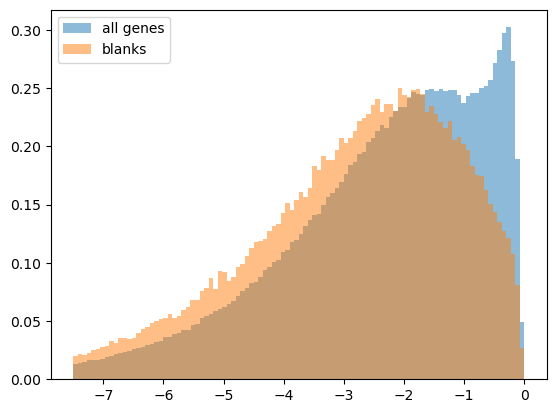

In [34]:
# Generate scores for the spots and plot all genes vs blanks (looking for clear separation)
get_score_withRef(dec,scoresRef,plt_val=True,gene=None,iSs = None,th_min=-7.5,include_dbits=True)

Text(0.5, 1.0, '0.4')

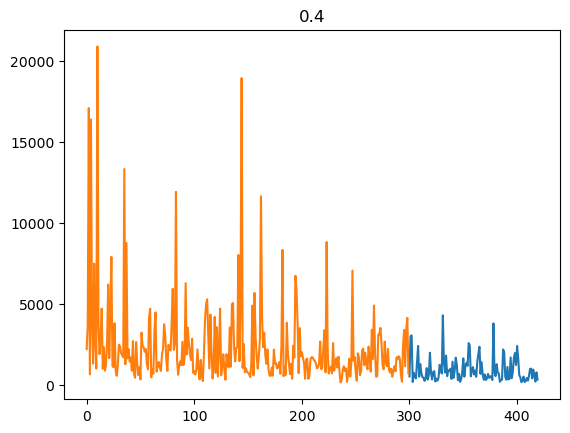

In [36]:
th=-1 #set this final threshold for scoreA based on above plot
XH_pruned = dec.XH_pruned
scoreA = dec.scoreA
icodesN = dec.icodesN
ibad = [ign for ign,gn in enumerate(dec.gns_names) if 'blank' in gn]
isbad = np.in1d(icodesN,ibad)
isgood=~isbad

XH_prunedf = XH_pruned[scoreA>th]
scoreAf = scoreA[scoreA>th]
icodesNf = icodesN[scoreA>th]
dist_bestf = dec.dist_best[scoreA>th]

_,cts = np.unique(list(dec.icodesN)+list(np.arange(len(dec.gns_names))),return_counts=True)
cts = cts-1
plt.figure()
plt.plot(ibad,cts[ibad])
igood = np.setdiff1d(np.arange(len(cts)),ibad)
plt.plot(igood,cts[igood])
plt.title(np.round(np.mean(cts[ibad])/np.mean(cts[igood]),2))

Fraction of GFP decoded above confidence: 0.7660431654676259


Text(0.5, 1.0, '0.4')

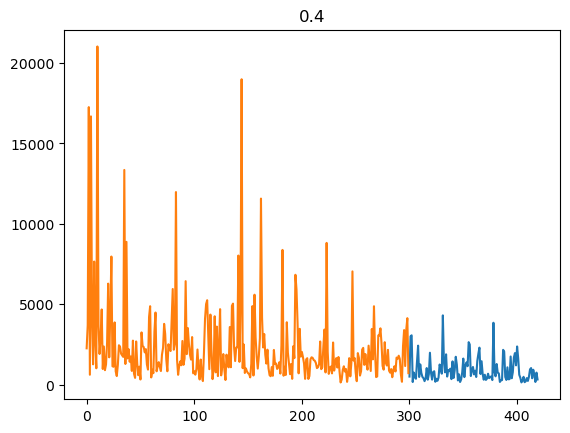

In [24]:
# load YFP spots to co-localize with the decoded spots
gfp_signal_col0 = save_folder+os.sep+dec.fov+r'--H17_MER--col0__Xhfits.npz'
gfp_signal_col1 = save_folder+os.sep+dec.fov+r'--H17_MER--col1__Xhfits.npz'
Xh0 = np.load(gfp_signal_col0)['Xh']
Xh1 = np.load(gfp_signal_col1)['Xh']

Xh0_ = Xh0[(Xh0[:,-2]>0.6)&(Xh0[:,-1]>np.exp(9.5))&(Xh0[:,-1]<np.exp(11))]### Threshold based on quality of spot
Xh1_ = Xh1[(Xh1[:,-2]>0.6)&(Xh1[:,-1]>np.exp(9.5))&(Xh1[:,-1]<np.exp(11))]
X0 = Xh0_[:,:3]
X1 = Xh1_[:,:3]

# Use KDTree for co-localization (distance between YFP/decoded spots)
from scipy.spatial import KDTree
dists,inds = KDTree(X0).query(X1)
X1F = Xh1_[(dists<2)][:,[0,1,2,-1]]

# Change to True to plot
if False:
    plt.hist(np.log(Xh0_[:,-1]),density=True,bins=30)
    plt.hist(np.log(Xh0_[inds[(dists<2)],-1]),density=True,bins=30,alpha=0.5)
    plt.hist(np.log(Xh1_[:,-1]),density=True,bins=30)
    plt.hist(np.log(Xh1_[dists<1.5,-1]),density=True,bins=30,alpha=0.5)

# Change to True to load YFP spots in napari
if False:
    imGFP = read_im(r'D:\241207_WTC11_SFv7\H17_MER'+os.sep+dec_new.fov)
    import napari
    V = napari.view_image(imGFP)
    V.add_points(X1F[:,:3],face_color=[0,0,0,0],edge_color='r')
    
### apply drift
drifts,flds,fov_,fl_ref = np.load(dec_new.drift_fl,allow_pickle=True)

from worker_ZaneWTC_HGFP import *
fl = r'D:\241207_WTC11_SFv7\H17_MER'+os.sep+dec_new.fov
drift = get_best_translation_pointsV2(fl,fl_ref,save_folder,'',resc=5)
X1FD = X1F.copy()
X1FD[:,:3]=X1F[:,:3]+drift[0]

X_MERFISH = np.nanmean(dec_new.XH_pruned[:,:,:3],axis=1)
tree = KDTree(X_MERFISH)
dist,indMER = tree.query(X1FD[:,:3],workers=10)

np.sum(dec_new.scoreA>th),np.sum(scoreA>th)
X1FD.shape,scoreA.shape
print("Fraction of GFP decoded above confidence:",np.sum(scoreA>th)/len(X1FD))

keepMER = indMER[dist<2]

th=-2 #set this final threshold for scoreA based on above plot
XH_pruned = dec_new.XH_pruned
scoreA = dec_new.scoreA
icodesN = dec_new.icodesN
ibad = [ign for ign,gn in enumerate(dec_new.gns_names) if 'blank' in gn]
isbad = np.in1d(icodesN,ibad)
isgood=~isbad

XH_prunedf = XH_pruned[scoreA>th]
scoreAf = scoreA[scoreA>th]
icodesNf = icodesN[scoreA>th]
dist_bestf = dec_new.dist_best[scoreA>th]

_,cts = np.unique(list(dec_new.icodesN)+list(np.arange(len(dec_new.gns_names))),return_counts=True)
cts = cts-1
plt.figure()
plt.plot(ibad,cts[ibad])
igood = np.setdiff1d(np.arange(len(cts)),ibad)
plt.plot(igood,cts[igood])
plt.title(np.round(np.mean(cts[ibad])/np.mean(cts[igood]),2))

In [322]:
cts

array([ 1424,  2750, 14146,   347, 11784,  2880,   618,  5770,  1717,
         509, 17316,  2910,  1367,  2207,  3810,   522,  1641,   551,
         826,  1794,  5018,  1271,  3740,  6245,   680,   773,  3166,
         565,   323,   678,  1654,  1799,  1440,  1281,  1245, 11026,
         810,  7066,  1005,  1525,   937,  1112,   558,  1946,   471,
         247,  1919,   803,   350,   654,   196,  2608,  1604,  1794,
        1458,  1664,   872,   522,  3027,  3890,   242,   619,   467,
        2509,  3693,   509,   685,   958,   629,   487,  1188,  1675,
        3041,  2373,  1055,   481,  1783,  1545,  1383,  3029,  4900,
        1393,  1868,  9680,  1085,   409,   738,   930,   803,  1951,
         872,  1140,  5312,  1482,  2693,  2018,  1197,  1162,  2005,
         504,   554,   446,   610,  1688,   657,   174,  1089,   257,
         118,  1298,  3154,  3921,  4175,  2345,   694,  3307,  1603,
         196,   755,  3583,   546,  2470,   351,  1551,  3715,   406,
         617,  1438,

Fraction of GFP decoded above confidence: 0.7660431654676259


Text(0.5, 1.0, '0.13')

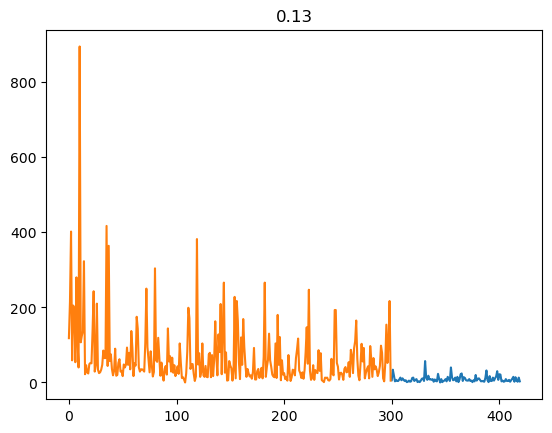

In [8]:
# load YFP spots to co-localize with the decoded spots
gfp_signal_col0 = save_folder+os.sep+dec.fov+r'--H17_MER--col0__Xhfits.npz'
gfp_signal_col1 = save_folder+os.sep+dec.fov+r'--H17_MER--col1__Xhfits.npz'
Xh0 = np.load(gfp_signal_col0)['Xh']
Xh1 = np.load(gfp_signal_col1)['Xh']

Xh0_ = Xh0[(Xh0[:,-2]>0.6)&(Xh0[:,-1]>np.exp(9.5))&(Xh0[:,-1]<np.exp(11))]### Threshold based on quality of spot
Xh1_ = Xh1[(Xh1[:,-2]>0.6)&(Xh1[:,-1]>np.exp(9.5))&(Xh1[:,-1]<np.exp(11))]
X0 = Xh0_[:,:3]
X1 = Xh1_[:,:3]

# Use KDTree for co-localization (distance between YFP/decoded spots)
from scipy.spatial import KDTree
dists,inds = KDTree(X0).query(X1)
X1F = Xh1_[(dists<2)][:,[0,1,2,-1]]

# Change to True to plot
if False:
    plt.hist(np.log(Xh0_[:,-1]),density=True,bins=30)
    plt.hist(np.log(Xh0_[inds[(dists<2)],-1]),density=True,bins=30,alpha=0.5)
    plt.hist(np.log(Xh1_[:,-1]),density=True,bins=30)
    plt.hist(np.log(Xh1_[dists<1.5,-1]),density=True,bins=30,alpha=0.5)

# Change to True to load YFP spots in napari
if False:
    imGFP = read_im(r'D:\241207_WTC11_SFv7\H17_MER'+os.sep+dec.fov)
    import napari
    V = napari.view_image(imGFP)
    V.add_points(X1F[:,:3],face_color=[0,0,0,0],edge_color='r')
    
### apply drift
drifts,flds,fov_,fl_ref = np.load(dec.drift_fl,allow_pickle=True)

from worker_ZaneWTC_HGFP import *
fl = r'D:\241207_WTC11_SFv7\H17_MER'+os.sep+dec.fov
drift = get_best_translation_pointsV2(fl,fl_ref,save_folder,'',resc=5)
X1FD = X1F.copy()
X1FD[:,:3]=X1F[:,:3]+drift[0]

X_MERFISH = np.nanmean(dec.XH_pruned[:,:,:3],axis=1)
tree = KDTree(X_MERFISH)
dist,indMER = tree.query(X1FD[:,:3],workers=10)

keepMER = indMER[dist<2]

th=-2 #set this final threshold for scoreA based on above plot
XH_pruned = dec.XH_pruned[keepMER]
scoreA = dec.scoreA[keepMER]
icodesN = dec.icodesN[keepMER]
ibad = [ign for ign,gn in enumerate(dec.gns_names) if 'blank' in gn]
isbad = np.in1d(icodesN,ibad)
isgood=~isbad


np.sum(dec.scoreA>th),np.sum(scoreA>th)
X1FD.shape,scoreA.shape
print("Fraction of GFP decoded above confidence:",np.sum(scoreA>th)/len(X1FD))

XH_prunedf = XH_pruned[scoreA>th]
scoreAf = scoreA[scoreA>th]
icodesNf = icodesN[scoreA>th]
dist_bestf = dec.dist_best[keepMER][scoreA>th]
# bigSpot = X1FD[dist<2][scoreA>th][:,-1]>np.exp(12)
#XH_prunedf = XH_pruned[scoreA>th]

# Plot the counts for decoded spots (genes & blanks) that co-localize with YFP in this fov
_,cts = np.unique(list(icodesNf)+list(np.arange(len(dec.gns_names))),return_counts=True)
cts = cts-1
plt.figure()
plt.plot(ibad,cts[ibad])
igood = np.setdiff1d(np.arange(len(cts)),ibad)
plt.plot(igood,cts[igood])
plt.title(np.round(np.mean(cts[ibad])/np.mean(cts[igood]),2))

### Look at decoded spots in Napari

In [17]:
import napari

In [18]:
V = napari.Viewer()

In [21]:
img = read_im(r'D:\241207_WTC11_SFv7\H9_MER\Conv_zscan1_030.zarr')
V.add_image(img)

<Image layer 'img' at 0x14c090de7d0>

In [22]:
CRE003 = np.where(dec.icodesN == 2)
V.add_points(dec.XH_pruned[CRE003][:,-1,:3], face_color='cyan', size=10)

<Points layer 'Points' at 0x14c0b325c00>

In [17]:
CRE003 = np.where(dec.icodesN[keepMER] == 2)
V.add_points(dec.XH_pruned[keepMER][CRE003][:,-1,:3], face_color='red', size=10)

<Points layer 'Points [1]' at 0x23a25e0cf10>

In [25]:
CRE003 = np.where(dec_new.icodesN == 2)
V.add_points(dec_new.XH_pruned[CRE003][:,-1,:3], face_color='yellow', size=10)

<Points layer 'Points' at 0x23a1874be20>

In [26]:
CRE003 = np.where(dec_new.icodesN[keepMER] == 2)
V.add_points(dec_new.XH_pruned[keepMER][CRE003][:,-1,:3], face_color='g', size=10)

<Points layer 'Points' at 0x23b80b0a290>

In [227]:
XH_pruned.shape

(25551, 6, 10)

In [246]:
cts

array([113, 207, 391,  56, 191, 194,  53, 274, 109,  40, 857, 105, 121,
       133, 317,  22,  43,  25,  24,  46,  46,  49, 133, 237,  27,  42,
       204,  33,  24,  26,  33,  45,  81,  61,  63, 411,  44, 359,  55,
        72,  36,  18,  31,  89,  17,  20,  46,  60,  28,  31,  17,  45,
        38,  45,  92,  42,  77,  34, 131,  88,  15,  50,  43, 175, 136,
        40,  29,  35,  32,  31,  28, 106, 247,  87,  57,  26,  81,  46,
        14,  25, 298,  56,  51, 110,  68,  17,  52,  19,   5,  35,  43,
        20, 139,  54,  61,  25,  64,  22,  43,  16,  26,  43,  23, 103,
        53,  12,  12,   7,   0,  22,  79, 193, 165,  34,  48,  43,  19,
         4,  15, 375,  48,  78,  13,  27,  97,  19,  15,  41,  12,  14,
        75,  77,  12,  59,  17,  59, 160,  68,  16, 127,  80, 205,  21,
       135, 256,  22,  79,   4,   6,  57,  44,  38,   5,  31, 221,  10,
       209, 161,  52,   8, 118,  43, 161,  86,  47,  14,  32,  24,  16,
        18,  10,  28,  91,   8,   8,  29,  34,  12,  21,  38,  1

In [281]:
# filter decoder object to keep spots that were decoded in both YFP colors (last 2 bits)
yfp_bits = np.where((dec.XH_pruned[:,-2,-1] == 48) & (dec.XH_pruned[:,-1,-1] == 49))
dec.XH_pruned[yfp_bits].shape

(340553, 6, 10)

In [333]:
dec.XH_pruned[yfp_bits][101]

array([[            nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan],
       [            nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan],
       [            nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan],
       [ 5.27416897e+00,  2.69377686e+03,  2.99457489e+02,
        -2.97750879e+03,  4.33489323e-01,  5.21910986e+03,
         6.72688305e-01,  8.91608008e+03,  0.00000000e+00,
         0.00000000e+00],
       [ 5.61647177e+00,  2.69278296e+03,  2.98999481e+02,
        -1.18135166e+04,  5.11123836e-01,  1.03533145e+04,
         6.00433826e-01,  2.28907363e+04,  0.00000000e+00,
         4.

In [18]:
def get_icodesV3_save(dec,save_object, nmin_bits=3,iH=-3):
    import time
    start = time.time()
    lens = dec.lens
    res_unfolder = dec.res_unfolder
    Mlen = np.max(lens)
    print("Calculating indexes within cluster...")
    res_is = np.tile(np.arange(Mlen), len(lens))
    res_is = res_is[res_is < np.repeat(lens, Mlen)]
    print("Calculating index of molecule...")
    ires = np.repeat(np.arange(len(lens)), lens)
    #r0 = np.array([r[0] for r in res for r_ in r])
    print("Calculating index of first molecule...")
    r0i = np.concatenate([[0],np.cumsum(lens)])[:-1]
    r0 = res_unfolder[np.repeat(r0i, lens)]
    print("Total time unfolded molecules:",time.time()-start)
    
    ### torch
    ires = torch.from_numpy(ires.astype(np.int64))
    res_unfolder = torch.from_numpy(res_unfolder.astype(np.int64))
    res_is = torch.from_numpy(res_is.astype(np.int64))
    
    import time
    start = time.time()
    print("Computing score...")
    scoreF = torch.from_numpy(dec.XH[:,iH])[res_unfolder]
    print("Total time computing score:",time.time()-start)
    
    
    ### organize molecules in blocks for each cluster
    def get_asort_scores():
        val = torch.max(scoreF)+2
        scoreClu = torch.zeros([len(lens),Mlen],dtype=torch.float64)+val
        scoreClu[ires,res_is]=scoreF
        asort = scoreClu.argsort(-1)
        scoreClu = torch.gather(scoreClu,dim=-1,index=asort)
        scoresF2 = scoreClu[scoreClu<val-1]
        return asort,scoresF2
    def get_reorder(x,val=-1):
        if type(x) is not torch.Tensor:
            x = torch.from_numpy(np.array(x))
        xClu = torch.zeros([len(lens),Mlen],dtype=x.dtype)+val
        xClu[ires,res_is] = x
        xClu = torch.gather(xClu,dim=-1,index=asort)
        xf = xClu[xClu>val]
        return xf
    
    
    import time
    start = time.time()
    print("Computing sorting...")
    asort,scoresF2 = get_asort_scores()
    res_unfolder2 = get_reorder(res_unfolder,val=-1)
    del asort
    del scoreF
    print("Total time sorting molecules by score:",time.time()-start)
    
    
    
    import time
    start = time.time()
    print("Finding best bits per molecules...")
    
    Rs = dec.XH[:,-1].astype(np.int64)
    Rs = torch.from_numpy(Rs)
    Rs_U = Rs[res_unfolder2]
    nregs,nbits = dec.codes_01.shape
    score_bits = torch.zeros([len(lens),nbits],dtype=scoresF2.dtype)-1
    score_bits[ires,Rs_U]=scoresF2
    
    
    codes_lib = torch.from_numpy(np.array(dec.codes__))
    
    
    codes_lib_01 = torch.zeros([len(codes_lib),nbits],dtype=score_bits.dtype)
    for icd,cd in enumerate(codes_lib):
        codes_lib_01[icd,cd]=1
    codes_lib_01 = codes_lib_01/torch.norm(codes_lib_01,dim=-1)[:,np.newaxis]
    print("Finding best code...")
    batch = 10000
    icodes_best = torch.zeros(len(score_bits),dtype=torch.int64)
    dists_best = torch.zeros(len(score_bits),dtype=torch.float32)
    from tqdm import tqdm
    for i in tqdm(range((len(score_bits)//batch)+1)):
        score_bits_ = score_bits[i*batch:(i+1)*batch]
        if len(score_bits_)>0:
            score_bits__ = score_bits_.clone()
            score_bits__[score_bits__==-1]=0
            score_bits__ = score_bits__/torch.norm(score_bits__,dim=-1)[:,np.newaxis]
            Mul = torch.matmul(score_bits__,codes_lib_01.T)
            max_ = torch.max(Mul,dim=-1)
            icodes_best[i*batch:(i+1)*batch] = max_.indices
            dists_best[i*batch:(i+1)*batch] = 2-2*max_.values
    
    
    keep_all_bits = torch.sum(score_bits.gather(1,codes_lib[icodes_best])>=0,-1)>=nmin_bits
    dists_best_ = dists_best[keep_all_bits]
    score_bits = score_bits[keep_all_bits]
    icodes_best_ = icodes_best[keep_all_bits]
    icodesN=icodes_best_
    
    indexMols_ = torch.zeros([len(lens),nbits],dtype=res_unfolder2.dtype)-1
    indexMols_[ires,Rs_U]=res_unfolder2
    indexMols_ = indexMols_[keep_all_bits]
    indexMols_ = indexMols_.gather(1,codes_lib[icodes_best_])
    
    # make unique
    indexMols_,rinvMols = get_unique_ordered(indexMols_)
    icodesN = icodesN[rinvMols]
    
    XH = torch.from_numpy(dec.XH)
    XH_pruned = XH[indexMols_]
    XH_pruned[indexMols_==-1]=np.nan
    
    dec.dist_best = dists_best_[rinvMols].numpy()
    dec.XH_pruned=XH_pruned.numpy()
    dec.icodesN=icodesN.numpy()
    if save_object:
        np.savez_compressed(dec.decoded_fl,XH_pruned=dec.XH_pruned,icodesN=dec.icodesN,gns_names = np.array(dec.gns_names),dist_best=dec.dist_best)
    print("Total time best bits per molecule:",time.time()-start)

In [19]:
def compute_decoding(save_folder,fov,set_,redo=False):
    dec = decoder_simple(save_folder,fov,set_)
    complete = dec.check_is_complete()
    if complete==0 or redo:
        #compute_drift(save_folder,fov,all_flds,set_,redo=False,gpu=False)
        dec = decoder_simple(save_folder,fov=fov,set_=set_)
        dec.get_XH(fov,set_,ncols=3,nbits=50,th_h=3600,tag_keep='MER')#number of colors match 
        dec.XH = dec.XH[dec.XH[:,-4]>0.25] ### keep the spots that are correlated with the expected PSF for 60X
        dec.load_library(lib_fl,nblanks=-1)
        dec.XH = dec.XH[dec.XH[:,-1]<50]
        dec.ncols = 3
        get_intersV2(dec,nmin_bits=5,dinstance_th=2,enforce_color=False,enforce_set=None,redo=True)
        get_icodesV3_save(dec,save_object = False, nmin_bits=5,iH=-3)
        #dec.get_inters(dinstance_th=2,enforce_color=True)# enforce_color=False
        #dec.get_inters(dinstance_th=2,nmin_bits=4,enforce_color=True,redo=True)
        #dec.get_icodes(nmin_bits=4,method = 'top4',norm_brightness=None,nbits=24)#,is_unique=False)
        #get_icodesV2(dec,nmin_bits=4,delta_bits=None,iH=-3,redo=False,norm_brightness=False,nbits=24,is_unique=True)
    return dec

In [20]:
dec_new = compute_decoding(save_folder,fov, set_='',redo=True)

Completed


  0%|                                                                                           | 0/18 [00:00<?, ?it/s]

(11985, 8)
(6453, 8)
(2972, 8)
(143814, 8)
(217472, 8)
(173527, 8)


 17%|█████████████▊                                                                     | 3/18 [00:00<00:02,  6.30it/s]

(139464, 8)
(212355, 8)
(171500, 8)


...

100%|██████████████████████████████████████████████████████████████████████████████████| 18/18 [00:03<00:00,  5.10it/s]

(19576, 8)


Calculating lengths of clusters...
Unfolding indexes...
Saving to file: D:\241207_WTC11_SFv7_HMERFISH_Analysis\resNew_Conv_zscan1_030--.npz
Calculating indexes within cluster...
Calculating index of molecule...
Calculating index of first molecule...
Total time unfolded molecules: 5.536999940872192
Computing score...
Total time computing score: 0.13900017738342285
Computing sorting...
Total time sorting molecules by score: 8.202000379562378
Finding best bits per molecules...
Finding best code...


100%|███████████████████████████████████████████████████████████████████████████████| 630/630 [00:00<00:00, 691.55it/s]


Total time best bits per molecule: 9.5350022315979


In [21]:
dec_new.XH_pruned.shape

(809205, 6, 10)

In [358]:
dec_new2.XH_pruned.shape

AttributeError: 'NoneType' object has no attribute 'XH_pruned'

In [361]:
dec_new2.XH_pruned

AttributeError: 'NoneType' object has no attribute 'XH_pruned'

In [47]:
def main_do_compute_fits(save_folder,fld,fov,icol,save_fl,psf,old_method):
    im_ = read_im(fld+os.sep+fov)
    im__ = np.array(im_[icol],dtype=np.float32)
    
    if old_method:
        ### previous method
        im_n = norm_slice(im__,s=30)
        #Xh = get_local_max(im_n,500,im_raw=im__,dic_psf=None,delta=1,delta_fit=3,dbscan=True,
        #      return_centers=False,mins=None,sigmaZ=1,sigmaXY=1.5)
        Xh = get_local_maxfast_tensor(im_n,th_fit=500,im_raw=im__,dic_psf=None,delta=1,delta_fit=3,sigmaZ=1,sigmaXY=1.5,gpu=False)
    else:
        ### new method
        fl_med = flat_field_tag+'med_col_raw'+str(icol)+'.npz'
        if os.path.exists(fl_med):
            im_med = np.array(np.load(fl_med)['im'],dtype=np.float32)
            im_med = cv2.blur(im_med,(20,20))
            im__ = im__/im_med*np.median(im_med)
            
            Xm = np.array([0,0,0])
            if bk_folder is not None:
                fl_ref = bk_folder+os.sep+fov
                tag_ = os.path.basename(fld)
                set_ =  '_set'+tag.split('_set')[-1] if '_set' in tag_ else ''
                drift = get_best_translation_pointsT(fl,save_folder,fl_ref,bk_folder,set_=set_)
                print(drift)
                from scipy.ndimage import shift
                im_bk = np.array(read_im(fl_ref)[icol],dtype=np.float32)
                im_bk_ = shift(im_bk/im_med,-drift[0],order=0,cval=np.nan)
                if True:
                    imr = im__/im_bk_
                    fr1p = np.nanpercentile(imr,1)
                    print(fr1p)
                fr1p = bk_frs[icol]
                im__ = im__-fr1p*im_bk_
                zb,xb,yb = np.where(~np.isnan(im__))
                xm,xM = np.min(xb),np.max(xb)+1
                ym,yM = np.min(yb),np.max(yb)+1
                zm,zM = np.min(zb),np.max(zb)+1
                im__ = im__[zm:zM,xm:xM,ym:yM]
                Xm = np.array([zm,xm,ym])
            print(im__.shape,zm,zM,xm,xM,ym,yM,np.sum(np.isnan(im__)))
        else:
            print("Did not find flat field")
        try:
            Xh = get_local_max_tile(im__,th=3600,s_ = 500,pad=100,psf=psf,plt_val=None,snorm=30,gpu=True,
                                    deconv={'method':'wiener','beta':0.0001},
                                    delta=1,delta_fit=3,sigmaZ=1,sigmaXY=1.5)
        except:
            Xh = get_local_max_tile(im__,th=3600,s_ = 500,pad=100,psf=psf,plt_val=None,snorm=30,gpu=False,
                                    deconv={'method':'wiener','beta':0.0001},
                                    delta=1,delta_fit=3,sigmaZ=1,sigmaXY=1.5)
                                    
    print(Xm)
    Xh[:,:3]=Xh[:,:3]+Xm
    np.savez_compressed(save_fl,Xh=Xh)

In [50]:
def get_iH(fld): 
    try:
        return int(os.path.basename(fld).split('_')[0][1:])
    except:
        return np.inf

def get_files(set_ifov,iHm=iHm,iHM=iHM):

    if not os.path.exists(save_folder): os.makedirs(save_folder)
    all_flds = []
    for master_folder in master_data_folder:

        all_flds += glob.glob(master_folder+r'\H*MER*')
    
    ### reorder based on hybe
    all_flds = np.array(all_flds)[np.argsort([get_iH(fld)for fld in all_flds])] 
    
    set_,ifov = set_ifov
    all_flds = [fld for fld in all_flds if set_ in os.path.basename(fld)]
    
    all_flds = [fld for fld in all_flds if ((get_iH(fld)>=iHm) and (get_iH(fld)<=iHM))]
    
    fovs_fl = save_folder+os.sep+'fovs__'+set_+'.npy'
    if not os.path.exists(fovs_fl):
        folder_map_fovs = all_flds[0]#[fld for fld in all_flds if 'low' not in os.path.basename(fld)][0]
        fls = glob.glob(folder_map_fovs+os.sep+'*.zarr')
        fovs = np.sort([os.path.basename(fl) for fl in fls])
        np.save(fovs_fl,fovs)
    else:
        fovs = np.sort(np.load(fovs_fl))
    fov=None
    if ifov<len(fovs):
        fov = fovs[ifov]
        all_flds = [fld for fld in all_flds if os.path.exists(fld+os.sep+fov)]
    return save_folder,all_flds,fov

In [53]:
def compute_fits(save_folder,fov,all_flds,redo=False,ncols=4,
                psf_file = psf_file,try_mode=True,old_method=False):
    psf = np.load(psf_file,allow_pickle=True)
    
    for fld in tqdm(all_flds):
        for icol in range(ncols-1):
            tag = os.path.basename(fld)
            save_fl = save_folder+os.sep+fov.split('.')[0]+'--'+tag+'--col'+str(icol)+'__Xhfits.npz'
            if not os.path.exists(save_fl) or redo:
                if try_mode:
                    try:
                        main_do_compute_fits(save_folder,fld,fov,icol,save_fl,psf,old_method)
                    except:
                        print("Failed",fld,fov,icol)
                else:
                    main_do_compute_fits(save_folder,fld,fov,icol,save_fl,psf,old_method)  

In [52]:
master_analysis_folder = r'C:\Users\zgibbs\Scripts'
lib_fl = r'C:\Users\zgibbs\Scripts\codebooks\codebookCRE300_schizo_GFP.csv' ### codebook
### Did you compute PSF and median flat field images?
psf_file = r'C:\Users\zgibbs\Scripts\psfs\psf_750_Scope4_final.npy'
master_data_folder = [r'D:\241207_WTC11_SFv7']
save_folder =r'D:\241207_WTC11_SFv7_HMERFISH_Analysis_redo_bk'  ###change
flat_field_tag = r'C:\Users\zgibbs\Scripts\psfs\Scope4_'

#H iHmin -> H iHmax only keeps folders of the the form H33,H34...
iHm=1 
iHM=17

# Specify the background round of imaging
bk_folder = 'D:\241207_WTC11_SFv7\H0_MER'
bk_frs = [1.15,1.1,1.05]

ifov = 30
fov = 'Conv_zscan1_'+str(ifov).zfill(3)

In [54]:
compute_fits(save_folder,fov,all_flds,redo=False,ncols=4,
                psf_file = psf_file,try_mode=True,old_method=False)

NameError: name 'all_flds' is not defined

In [55]:
im_ = read_im(fld+os.sep+fov)

NameError: name 'fld' is not defined